# Task 3: Simple Linear Regression Model

## Objective

The objective of this task is to build a simple linear regression model using the Superstore Sales dataset.

The model will analyze the relationship between the time of an order and its sales value. The order date will be transformed into the number of days since the first recorded order, which will be used as the independent variable.

The model will then be trained, evaluated, and visualized using a regression line.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
df = pd.read_csv("../Task1 - Data Cleaning/Cleaned_Superstore.csv")

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [11]:
df["Order Date"].dtype

dtype('O')

In [14]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

In [15]:
df["Order Date"].dtype

dtype('<M8[ns]')

In [16]:
df["Days_Since_First_Order"] = (
    df["Order Date"] - df["Order Date"].min()
).dt.days

In [17]:
df[["Order Date", "Days_Since_First_Order", "Sales"]].head()

,Order Date,Days_Since_First_Order,Sales
0,2017-11-08,1040,261.9600
1,2017-11-08,1040,731.9400
2,2017-06-12,891,14.6200
3,2016-10-11,647,957.5775
4,2016-10-11,647,22.3680


In [18]:
X = df[["Days_Since_First_Order"]]
y = df["Sales"]

In [20]:
df[["Days_Since_First_Order"]]

,Days_Since_First_Order
0,1040
1,1040
2,891
3,647
4,647
...,...
9795,869
9796,374
9797,374
9798,374


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
model= LinearRegression()

In [24]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred = model.predict(X_test)

In [26]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,47.940,217.529888
1,11.360,224.788648
2,10.950,223.948312
3,17.480,218.239826
4,21.120,224.651006
5,88.832,222.072046
6,6.672,217.580597
7,22.480,221.383840
8,251.580,217.174918
9,38.256,225.397166


In [27]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.007244271465260169
Intercept: 227.25894414611224


In [28]:
print(
    f"Regression Equation: Sales = {model.coef_[0]:.4f} × Days_Since_First_Order + {model.intercept_:.2f}"
)

Regression Equation: Sales = -0.0072 × Days_Since_First_Order + 227.26


In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 303.058894465283
Mean Squared Error: 670622.9640352527
Root Mean Squared Error: 818.9157246232684
R² Score: -0.0033260963992469694


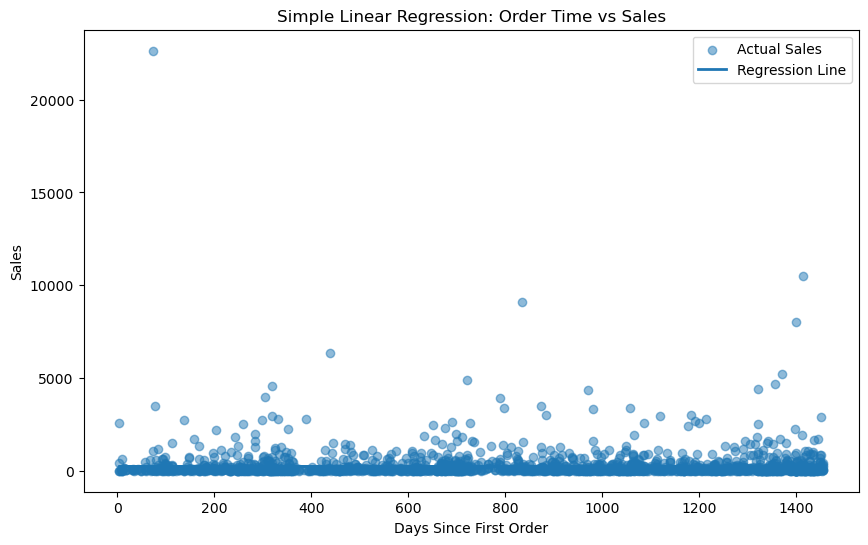

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.5, label="Actual Sales")
plt.plot(
    X_test,
    y_pred,
    linewidth=2,
    label="Regression Line"
)
plt.title("Simple Linear Regression: Order Time vs Sales")
plt.xlabel("Days Since First Order")
plt.ylabel("Sales")
plt.legend()
plt.show()

## Model Interpretation

The linear regression model attempts to identify a relationship between the time of an order and its sales value.

The regression line represents the sales value predicted by the model based on the number of days since the first recorded order.

The R² score indicates how well the order time explains variations in individual sales. If the R² score is low, it suggests that order date alone is not sufficient to accurately predict individual transaction sales. Other factors such as product category, customer segment, product type, and region may have a stronger influence on sales.

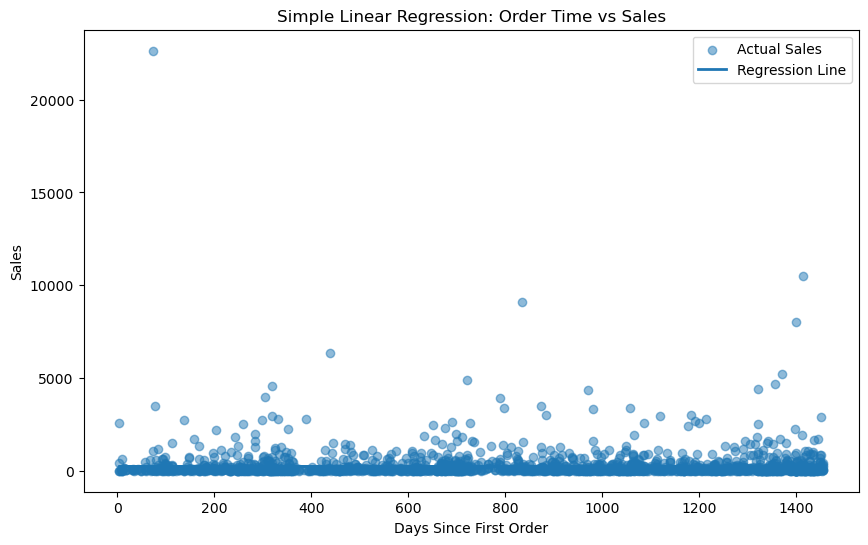

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual Sales"
)
plt.plot(
    X_test,
    y_pred,
    linewidth=2,
    label="Regression Line"
)
plt.title("Simple Linear Regression: Order Time vs Sales")
plt.xlabel("Days Since First Order")
plt.ylabel("Sales")
plt.legend()
plt.savefig(
    "regression_line.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Conclusion

A simple linear regression model was developed using the Superstore Sales dataset. The number of days since the first recorded order was used as the independent variable, while Sales was used as the dependent variable.

The model was trained using 80% of the data and evaluated using the remaining 20%. Evaluation metrics such as MAE, RMSE, and R² were used to measure the model's performance.

The regression analysis helped demonstrate the complete machine learning workflow, including data preparation, model training, prediction, evaluation, and visualization. The results also show that sales are influenced by several factors and cannot necessarily be explained by order time alone.